# Fase II -- Entrenamiento y Evaluacion de Baselines

Este notebook entrena los **3 modelos baseline** sobre Tox21 y genera graficos de desempeno.
Los baselines son modelos de referencia contra los cuales compararemos la GNN-GIN en la Fase III.

| Baseline | Representacion | Arquitectura | AUC esperado (scaffold split) |
|---|---|---|---|
| **Random Forest** | Morgan ECFP4 (2048 bits) | 800 arboles por tarea | ~0.72-0.76 |
| **MLP** | Morgan ECFP4 (2048 bits) | 2048-512-256-12 | ~0.74-0.78 |
| **SMILES2vec** | Texto SMILES (250 chars) | Embedding-CNN-BiGRU-12 | ~0.75-0.80 |

**Regla de sanidad:** Si el RF no alcanza AUC > 0.65, hay un bug en los datos.

---

### Por que baselines?

Sin baselines no sabemos si la GNN aporta valor real. Si un Random Forest con fingerprints
simples ya alcanza AUC 0.76, la GNN necesita superar ese numero para justificar su complejidad.
Los 3 modelos usan representaciones moleculares progresivamente mas ricas:

1. **RF**: Solo presencia/ausencia de subestructuras (fingerprint binario)
2. **MLP**: Lo mismo pero con capas no lineales que capturan interacciones
3. **SMILES2vec**: Lee la secuencia SMILES como texto, captura patrones secuenciales
4. **GNN-GIN** (Fase III): Opera directamente sobre el grafo molecular

## 0. Configuracion

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_curve
from scipy import stats

from scripts.prepare_tox21_graphs import _extract_smiles_y_mask
from src.data.dataset import N_TASKS, TASK_NAMES
from src.evaluation.cross_validation import (
    evaluate_multitask_auc,
    evaluate_multitask_auprc,
)
from src.models.baselines import (
    MLPBaseline,
    RandomForestBaseline,
    SMILES2vec,
    morgan_fingerprints,
    smiles_to_indices,
)
from src.training.loss import MaskedBCELoss

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120})

OUT_DIR = ROOT / "outputs" / "results"
FIG_DIR = ROOT / "outputs" / "baselines"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Graficos se guardan en: {FIG_DIR}")

c:\Users\mateo\Desktop\JIC2026\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda
Graficos se guardan en: c:\Users\mateo\Desktop\JIC2026\outputs\baselines


## 1. Carga de datos

In [2]:
from src.data.tox21_deepchem import load_tox21_raw_scaffold

print("Cargando Tox21 desde DeepChem (scaffold split)...")
_tasks, splits, _transformers = load_tox21_raw_scaffold()
train_ds, val_ds, test_ds = splits

smi_tr, y_tr, mask_tr = _extract_smiles_y_mask(train_ds)
smi_va, y_va, mask_va = _extract_smiles_y_mask(val_ds)
smi_te, y_te, mask_te = _extract_smiles_y_mask(test_ds)

print(f"  Train: {len(smi_tr):,} | Val: {len(smi_va):,} | Test: {len(smi_te):,}")
print(f"  Tareas: {N_TASKS}")

# RF usa train+val porque no tiene early stopping
smi_rf = smi_tr + smi_va
y_rf = np.concatenate([y_tr, y_va], axis=0)
mask_rf = np.concatenate([mask_tr, mask_va], axis=0)
print(f"  RF usara train+val: {len(smi_rf):,} moleculas")

Cargando Tox21 desde DeepChem (scaffold split)...


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\mateo\Desktop\JIC2026\.venv\lib\site-packages\dee

  Train: 6,258 | Val: 782 | Test: 783
  Tareas: 12
  RF usara train+val: 7,040 moleculas


## 2. Baseline 1: Random Forest + Morgan ECFP4

El Random Forest entrena **un clasificador separado por tarea** usando solo las moleculas
que tienen medicion para esa tarea. Usa `class_weight='balanced_subsample'` para compensar
el desbalance. No requiere validacion para early stopping, asi que usa train+val combinados.

In [3]:
print("=== Entrenando Random Forest (800 arboles, 12 tareas independientes) ===")
t0 = time.time()

rf = RandomForestBaseline(verbose=True)
rf.fit(smi_rf, y_rf, mask_rf)
preds_rf = rf.predict_proba(smi_te)

auc_rf, mean_rf = evaluate_multitask_auc(y_te, preds_rf, mask_te, TASK_NAMES)
auprc_rf, mean_auprc_rf = evaluate_multitask_auprc(y_te, preds_rf, mask_te, TASK_NAMES)

t_rf = time.time() - t0
print(f"\nResultado RF -- AUC-ROC medio: {mean_rf:.4f} | AUPRC medio: {mean_auprc_rf:.4f}")
print(f"Tiempo: {t_rf:.1f}s")

if mean_rf < 0.65:
    print("\n[ALERTA] AUC < 0.65 -- posible problema con los datos!")
else:
    print("Verificacion de sanidad OK (AUC > 0.65)")

=== Entrenando Random Forest (800 arboles, 12 tareas independientes) ===


[23:58:14] WARNING: not removing hydrogen atom without neighbors


    [1/12] RandomForest (n=6543, positivos=281, árboles=800)...
    [2/12] RandomForest (n=6127, positivos=218, árboles=800)...
    [3/12] RandomForest (n=5913, positivos=676, árboles=800)...
    [4/12] RandomForest (n=5292, positivos=253, árboles=800)...
    [5/12] RandomForest (n=5632, positivos=721, árboles=800)...
    [6/12] RandomForest (n=6295, positivos=328, árboles=800)...
    [7/12] RandomForest (n=5868, positivos=164, árboles=800)...
    [8/12] RandomForest (n=5344, positivos=824, árboles=800)...
    [9/12] RandomForest (n=6393, positivos=231, árboles=800)...
    [10/12] RandomForest (n=5888, positivos=325, árboles=800)...
    [11/12] RandomForest (n=5284, positivos=822, árboles=800)...
    [12/12] RandomForest (n=6137, positivos=351, árboles=800)...
    RF predict_proba tarea 1/12...
    RF predict_proba tarea 2/12...
    RF predict_proba tarea 3/12...
    RF predict_proba tarea 4/12...
    RF predict_proba tarea 5/12...
    RF predict_proba tarea 6/12...
    RF predict_prob

## 3. Baseline 2: MLP + Morgan ECFP4

El MLP recibe los mismos fingerprints Morgan pero los procesa con capas no lineales
(2048-512-256-12 con BatchNorm, ReLU y Dropout). Usa early stopping sobre validacion
para evitar sobreajuste.

In [4]:
print("Calculando fingerprints Morgan ECFP4...")
X_tr = morgan_fingerprints(smi_tr)
X_va = morgan_fingerprints(smi_va)
X_te = morgan_fingerprints(smi_te)
print(f"  Dimensiones: train {X_tr.shape}, val {X_va.shape}, test {X_te.shape}")

Calculando fingerprints Morgan ECFP4...


[00:01:30] WARNING: not removing hydrogen atom without neighbors


  Dimensiones: train (6258, 2048), val (782, 2048), test (783, 2048)


In [5]:
def train_mlp_with_history(
    X_tr, y_tr, mask_tr, X_va, y_va, mask_va,
    device, epochs=60, batch_size=256,
):
    """Entrena MLP y retorna modelo e historial de entrenamiento."""
    y_tr_t = torch.nan_to_num(torch.tensor(y_tr, dtype=torch.float32), nan=0.0)
    m_tr_t = torch.tensor(mask_tr, dtype=torch.bool)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_tr, dtype=torch.float32), y_tr_t, m_tr_t),
        batch_size=batch_size, shuffle=True,
    )
    model = MLPBaseline(n_tasks=N_TASKS).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = MaskedBCELoss()

    history = {"epoch": [], "loss": [], "val_auc": []}
    best_val_auc = 0.0
    patience, bad = 10, 0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        total_loss, n_batch = 0.0, 0
        for xb, yb, mb in loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb, mb)
            loss.backward()
            opt.step()
            total_loss += float(loss.detach())
            n_batch += 1
        avg_loss = total_loss / max(n_batch, 1)

        model.eval()
        with torch.no_grad():
            x_v = torch.tensor(X_va, dtype=torch.float32, device=device)
            val_preds = torch.sigmoid(model(x_v)).cpu().numpy()
        _, val_auc = evaluate_multitask_auc(y_va, val_preds, mask_va, TASK_NAMES)

        history["epoch"].append(ep)
        history["loss"].append(avg_loss)
        history["val_auc"].append(val_auc)

        if np.isfinite(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            bad = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1

        if ep % 10 == 0 or ep == 1:
            marker = "*" if bad == 0 else ""
            print(f"  Epoca {ep:3d} -- loss: {avg_loss:.4f}  val_auc: {val_auc:.4f}  {marker}")

        if bad >= patience:
            print(f"  Early stopping en epoca {ep} (mejor val_auc: {best_val_auc:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


print("=== Entrenando MLP (2048-512-256-12, early stopping patience=10) ===")
t0 = time.time()
mlp_model, mlp_history = train_mlp_with_history(
    X_tr, y_tr, mask_tr, X_va, y_va, mask_va, device
)
t_mlp = time.time() - t0

mlp_model.eval()
with torch.no_grad():
    x_t = torch.tensor(X_te, dtype=torch.float32, device=device)
    preds_mlp = torch.sigmoid(mlp_model(x_t)).cpu().numpy()

auc_mlp, mean_mlp = evaluate_multitask_auc(y_te, preds_mlp, mask_te, TASK_NAMES)
auprc_mlp, mean_auprc_mlp = evaluate_multitask_auprc(y_te, preds_mlp, mask_te, TASK_NAMES)

print(f"\nResultado MLP -- AUC-ROC medio: {mean_mlp:.4f} | AUPRC medio: {mean_auprc_mlp:.4f}")
print(f"Tiempo: {t_mlp:.1f}s")

=== Entrenando MLP (2048-512-256-12, early stopping patience=10) ===
  Epoca   1 -- loss: 0.4112  val_auc: 0.7044  *
  Epoca  10 -- loss: 0.0510  val_auc: 0.7223  
  Early stopping en epoca 15 (mejor val_auc: 0.7434)

Resultado MLP -- AUC-ROC medio: 0.7071 | AUPRC medio: 0.3136
Tiempo: 4.2s


## 4. Baseline 3: SMILES2vec (CNN-GRU)

SMILES2vec lee la cadena SMILES como texto: cada caracter se convierte en un
embedding (50 dims), pasa por Conv1D (patrones de 3 caracteres), y luego por
un GRU bidireccional de 2 capas que captura dependencias a lo largo de la secuencia.

In [6]:
def smiles_to_idx_matrix(smiles_list, max_len=250):
    """Convierte lista de SMILES a matriz de indices enteros."""
    return np.array([smiles_to_indices(s, max_len) for s in smiles_list], dtype=np.int64)


def train_s2v_with_history(
    smi_tr, y_tr, mask_tr, smi_va, y_va, mask_va,
    device, epochs=40, batch_size=128,
):
    """Entrena SMILES2vec y retorna modelo e historial."""
    X_tr = smiles_to_idx_matrix(smi_tr)
    X_va = smiles_to_idx_matrix(smi_va)

    y_tr_t = torch.nan_to_num(torch.tensor(y_tr, dtype=torch.float32), nan=0.0)
    m_tr_t = torch.tensor(mask_tr, dtype=torch.bool)
    loader = DataLoader(
        TensorDataset(torch.tensor(X_tr, dtype=torch.long), y_tr_t, m_tr_t),
        batch_size=batch_size, shuffle=True,
    )
    model = SMILES2vec(n_tasks=N_TASKS).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = MaskedBCELoss()

    history = {"epoch": [], "loss": [], "val_auc": []}
    best_val_auc = 0.0
    patience, bad = 8, 0
    best_state = None

    x_va_t = torch.tensor(X_va, dtype=torch.long, device=device)

    for ep in range(1, epochs + 1):
        model.train()
        total_loss, n_batch = 0.0, 0
        for xb, yb, mb in loader:
            xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb, mb)
            loss.backward()
            opt.step()
            total_loss += float(loss.detach())
            n_batch += 1
        avg_loss = total_loss / max(n_batch, 1)

        model.eval()
        with torch.no_grad():
            preds_chunks = []
            for start in range(0, len(X_va), 256):
                chunk = x_va_t[start:start+256]
                preds_chunks.append(torch.sigmoid(model(chunk)).cpu())
            val_preds = torch.cat(preds_chunks, dim=0).numpy()
        _, val_auc = evaluate_multitask_auc(y_va, val_preds, mask_va, TASK_NAMES)

        history["epoch"].append(ep)
        history["loss"].append(avg_loss)
        history["val_auc"].append(val_auc)

        if np.isfinite(val_auc) and val_auc > best_val_auc:
            best_val_auc = val_auc
            bad = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1

        if ep % 5 == 0 or ep == 1:
            marker = "*" if bad == 0 else ""
            print(f"  Epoca {ep:3d} -- loss: {avg_loss:.4f}  val_auc: {val_auc:.4f}  {marker}")

        if bad >= patience:
            print(f"  Early stopping en epoca {ep} (mejor val_auc: {best_val_auc:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


print("=== Entrenando SMILES2vec (Embedding-CNN-BiGRU, early stopping patience=8) ===")
t0 = time.time()
s2v_model, s2v_history = train_s2v_with_history(
    smi_tr, y_tr, mask_tr, smi_va, y_va, mask_va, device
)
t_s2v = time.time() - t0

X_te_s2v = smiles_to_idx_matrix(smi_te)
s2v_model.eval()
with torch.no_grad():
    x_t = torch.tensor(X_te_s2v, dtype=torch.long, device=device)
    chunks = []
    for start in range(0, len(X_te_s2v), 256):
        chunks.append(torch.sigmoid(s2v_model(x_t[start:start+256])).cpu())
    preds_s2v = torch.cat(chunks, dim=0).numpy()

auc_s2v, mean_s2v = evaluate_multitask_auc(y_te, preds_s2v, mask_te, TASK_NAMES)
auprc_s2v, mean_auprc_s2v = evaluate_multitask_auprc(y_te, preds_s2v, mask_te, TASK_NAMES)

print(f"\nResultado SMILES2vec -- AUC-ROC medio: {mean_s2v:.4f} | AUPRC medio: {mean_auprc_s2v:.4f}")
print(f"Tiempo: {t_s2v:.1f}s")

=== Entrenando SMILES2vec (Embedding-CNN-BiGRU, early stopping patience=8) ===
  Epoca   1 -- loss: 0.2592  val_auc: 0.6515  *
  Epoca   5 -- loss: 0.1873  val_auc: 0.7460  *
  Epoca  10 -- loss: 0.1564  val_auc: 0.7409  
  Epoca  15 -- loss: 0.1223  val_auc: 0.7392  
  Early stopping en epoca 15 (mejor val_auc: 0.7545)

Resultado SMILES2vec -- AUC-ROC medio: 0.7268 | AUPRC medio: 0.3110
Tiempo: 157.3s


## 5. Tabla comparativa de resultados

In [7]:
MODELOS = ["Random Forest", "MLP", "SMILES2vec"]
COLORES = ["#3498db", "#e67e22", "#9b59b6"]
aucs_dict_list = [auc_rf, auc_mlp, auc_s2v]
auprcs_dict_list = [auprc_rf, auprc_mlp, auprc_s2v]
medias_auc = [mean_rf, mean_mlp, mean_s2v]
medias_auprc = [mean_auprc_rf, mean_auprc_mlp, mean_auprc_s2v]
tiempos = [t_rf, t_mlp, t_s2v]
all_preds = [preds_rf, preds_mlp, preds_s2v]

auc_matrix = np.zeros((3, N_TASKS))
for i, auc_d in enumerate(aucs_dict_list):
    for j, t_name in enumerate(TASK_NAMES):
        auc_matrix[i, j] = auc_d.get(t_name, 0.5)

In [8]:
filas = []
for i, nombre in enumerate(MODELOS):
    fila = {"Modelo": nombre}
    for t_name in TASK_NAMES:
        fila[t_name] = aucs_dict_list[i].get(t_name, np.nan)
    fila["Media AUC-ROC"] = medias_auc[i]
    fila["Media AUPRC"] = medias_auprc[i]
    fila["Tiempo (s)"] = tiempos[i]
    filas.append(fila)

df_resultados = pd.DataFrame(filas)
cols_format = {t: "{:.3f}" for t in TASK_NAMES + ["Media AUC-ROC", "Media AUPRC"]}
cols_format["Tiempo (s)"] = "{:.0f}"
df_resultados.style.format(cols_format).highlight_max(
    subset=TASK_NAMES + ["Media AUC-ROC", "Media AUPRC"],
    color="#d4edda",
)

,Modelo,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-AtAD5,SR-HSE,SR-MMP,SR-p53,Media AUC-ROC,Media AUPRC,Tiempo (s)
0,Random Forest,0.701,0.848,0.831,0.713,0.649,0.651,0.743,0.691,0.782,0.733,0.812,0.766,0.743,0.386,196
1,MLP,0.746,0.780,0.770,0.696,0.658,0.658,0.605,0.692,0.724,0.692,0.749,0.715,0.707,0.314,4
2,SMILES2vec,0.729,0.787,0.810,0.718,0.702,0.741,0.689,0.673,0.701,0.718,0.778,0.676,0.727,0.311,157


In [9]:
df_resultados.to_csv(OUT_DIR / "baseline_results.csv", index=False)
print(f"Resultados guardados en {OUT_DIR / 'baseline_results.csv'}")

Resultados guardados en c:\Users\mateo\Desktop\JIC2026\outputs\results\baseline_results.csv


---
## 6. AUC-ROC por tarea (grafico principal)

Este es el grafico mas importante: muestra como cada baseline se desempena en cada
una de las 12 tareas de toxicidad.

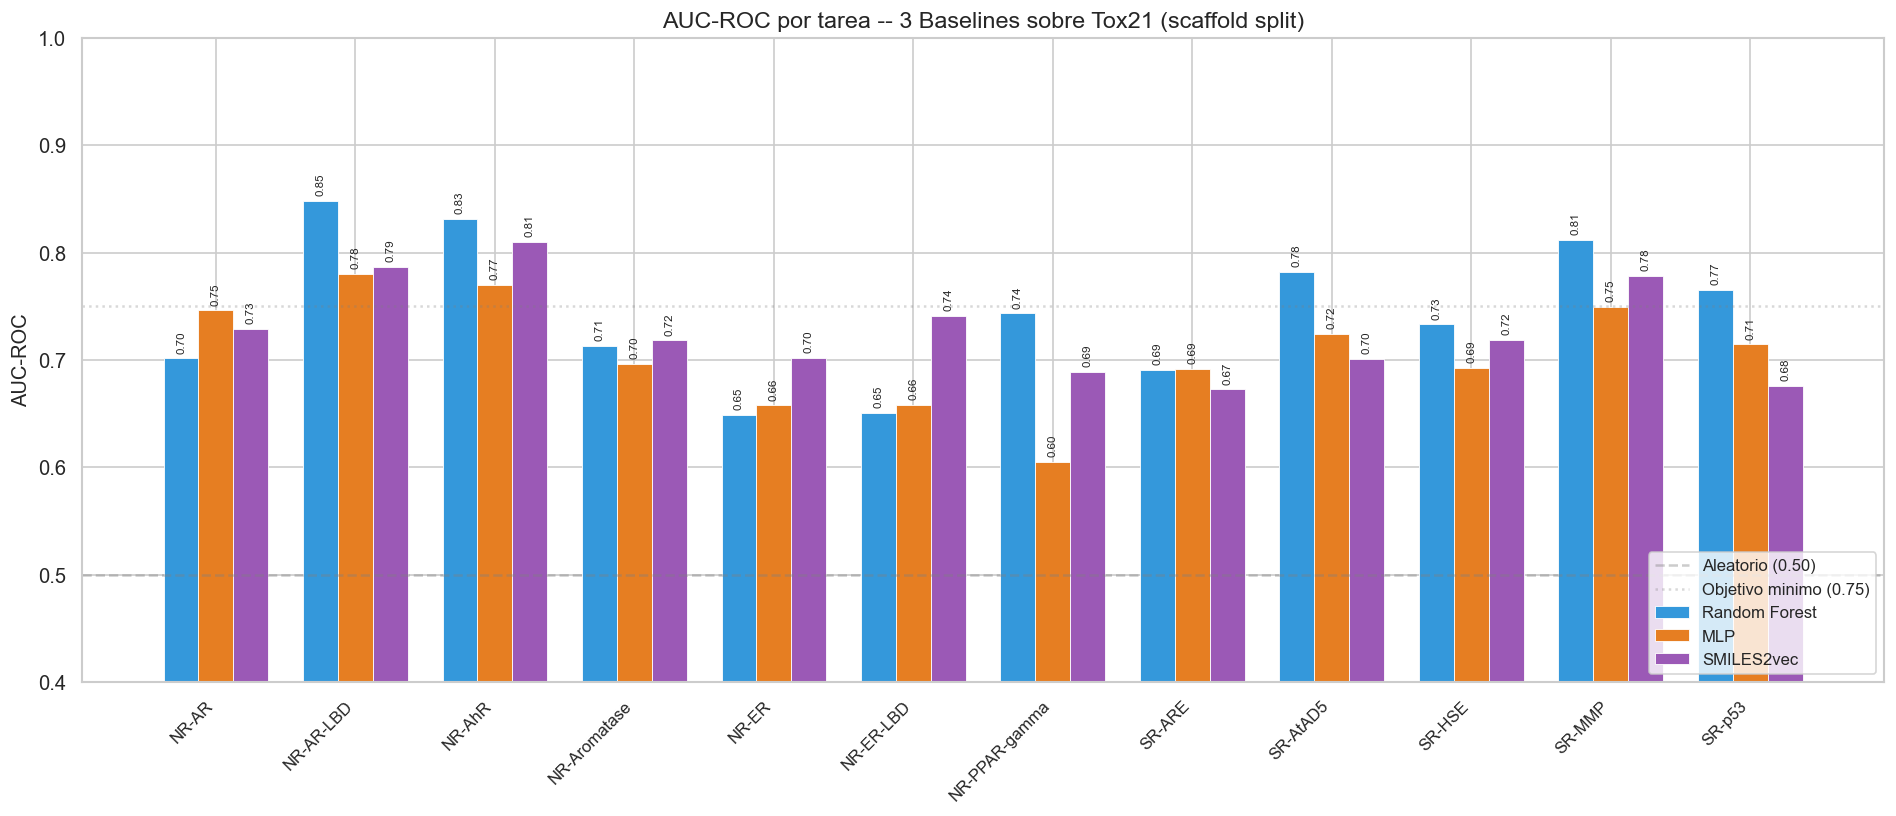

In [10]:
fig, ax = plt.subplots(figsize=(16, 7))
x = np.arange(N_TASKS)
ancho = 0.25

for i, (nombre, color) in enumerate(zip(MODELOS, COLORES)):
    offset = (i - 1) * ancho
    bars = ax.bar(x + offset, auc_matrix[i], ancho, label=nombre,
                  color=color, edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, auc_matrix[i]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", fontsize=7, rotation=90, va="bottom")

ax.set_xticks(x)
ax.set_xticklabels(TASK_NAMES, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_title("AUC-ROC por tarea -- 3 Baselines sobre Tox21 (scaffold split)", fontsize=14)
ax.set_ylim(0.4, 1.0)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4, label="Aleatorio (0.50)")
ax.axhline(y=0.75, color="gray", linestyle=":", alpha=0.3, label="Objetivo minimo (0.75)")
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_auc_por_tarea.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Comparacion de medias con referencia de literatura

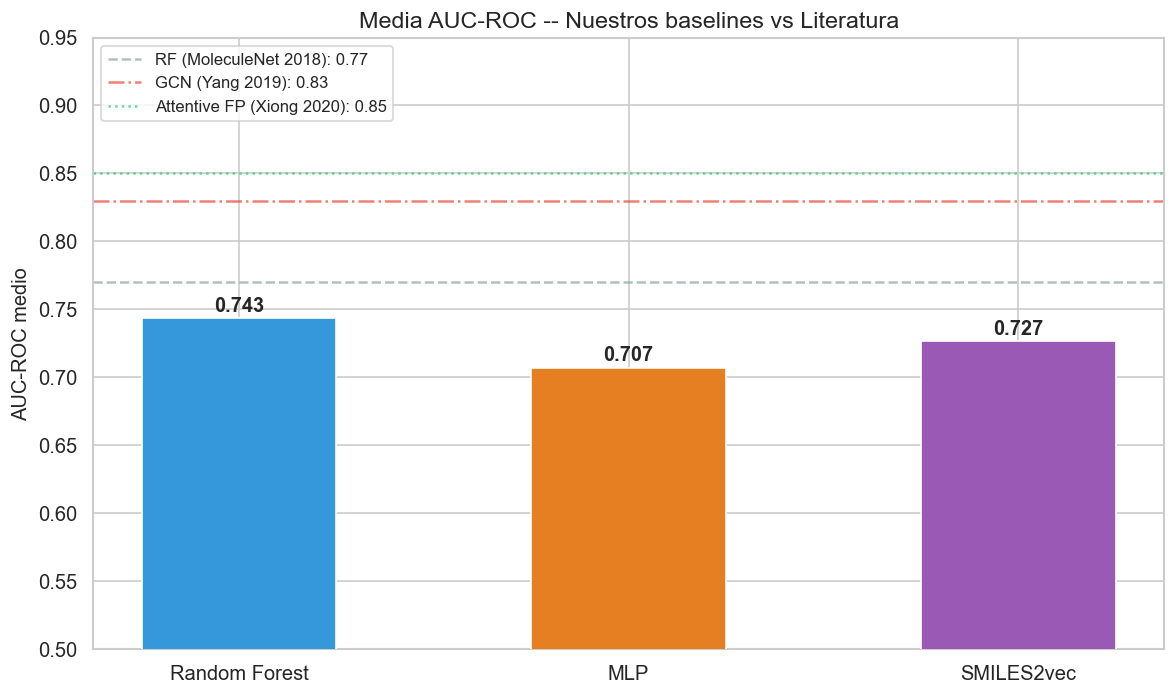

In [11]:
ref_literature = {
    "RF (MoleculeNet 2018)": 0.77,
    "GCN (Yang 2019)": 0.83,
    "Attentive FP (Xiong 2020)": 0.85,
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(MODELOS, medias_auc, color=COLORES, edgecolor="white", width=0.5, zorder=3)
for bar, val in zip(bars, medias_auc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")

estilos = ["--", "-.", ":"]
colores_ref = ["#95a5a6", "#e74c3c", "#2ecc71"]
for (ref_name, ref_val), estilo, color in zip(ref_literature.items(), estilos, colores_ref):
    ax.axhline(y=ref_val, linestyle=estilo, color=color, alpha=0.7,
               label=f"{ref_name}: {ref_val:.2f}")

ax.set_ylabel("AUC-ROC medio", fontsize=12)
ax.set_title("Media AUC-ROC -- Nuestros baselines vs Literatura", fontsize=14)
ax.set_ylim(0.5, 0.95)
ax.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_media_vs_literatura.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Curvas de entrenamiento (MLP y SMILES2vec)

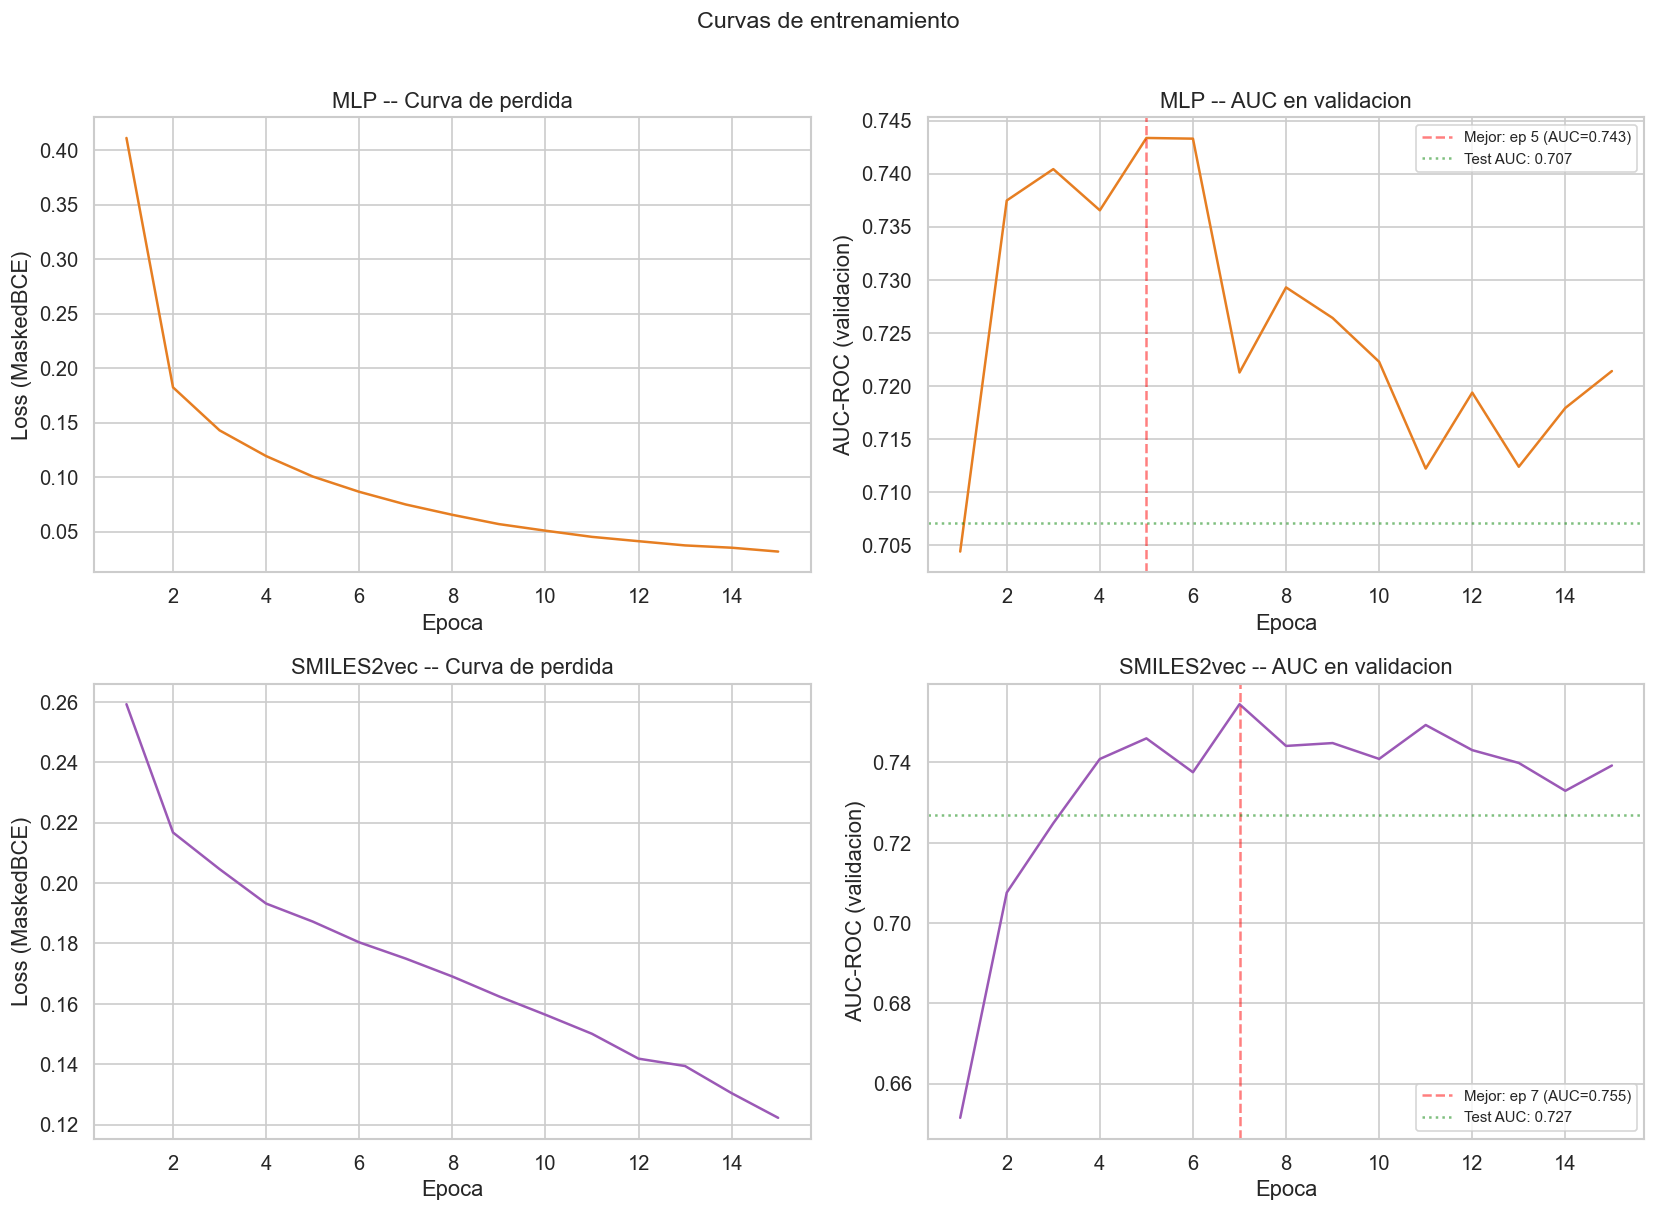

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(mlp_history["epoch"], mlp_history["loss"], color="#e67e22", linewidth=1.5)
axes[0, 0].set_xlabel("Epoca")
axes[0, 0].set_ylabel("Loss (MaskedBCE)")
axes[0, 0].set_title("MLP -- Curva de perdida")

axes[0, 1].plot(mlp_history["epoch"], mlp_history["val_auc"], color="#e67e22", linewidth=1.5)
best_ep_mlp = mlp_history.loc[mlp_history["val_auc"].idxmax()]
axes[0, 1].axvline(best_ep_mlp["epoch"], color="red", linestyle="--", alpha=0.5,
                    label=f"Mejor: ep {int(best_ep_mlp['epoch'])} (AUC={best_ep_mlp['val_auc']:.3f})")
axes[0, 1].axhline(mean_mlp, color="green", linestyle=":", alpha=0.5,
                    label=f"Test AUC: {mean_mlp:.3f}")
axes[0, 1].set_xlabel("Epoca")
axes[0, 1].set_ylabel("AUC-ROC (validacion)")
axes[0, 1].set_title("MLP -- AUC en validacion")
axes[0, 1].legend(fontsize=9)

axes[1, 0].plot(s2v_history["epoch"], s2v_history["loss"], color="#9b59b6", linewidth=1.5)
axes[1, 0].set_xlabel("Epoca")
axes[1, 0].set_ylabel("Loss (MaskedBCE)")
axes[1, 0].set_title("SMILES2vec -- Curva de perdida")

axes[1, 1].plot(s2v_history["epoch"], s2v_history["val_auc"], color="#9b59b6", linewidth=1.5)
best_ep_s2v = s2v_history.loc[s2v_history["val_auc"].idxmax()]
axes[1, 1].axvline(best_ep_s2v["epoch"], color="red", linestyle="--", alpha=0.5,
                    label=f"Mejor: ep {int(best_ep_s2v['epoch'])} (AUC={best_ep_s2v['val_auc']:.3f})")
axes[1, 1].axhline(mean_s2v, color="green", linestyle=":", alpha=0.5,
                    label=f"Test AUC: {mean_s2v:.3f}")
axes[1, 1].set_xlabel("Epoca")
axes[1, 1].set_ylabel("AUC-ROC (validacion)")
axes[1, 1].set_title("SMILES2vec -- AUC en validacion")
axes[1, 1].legend(fontsize=9)

plt.suptitle("Curvas de entrenamiento", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Heatmap de desempeno por modelo y tarea

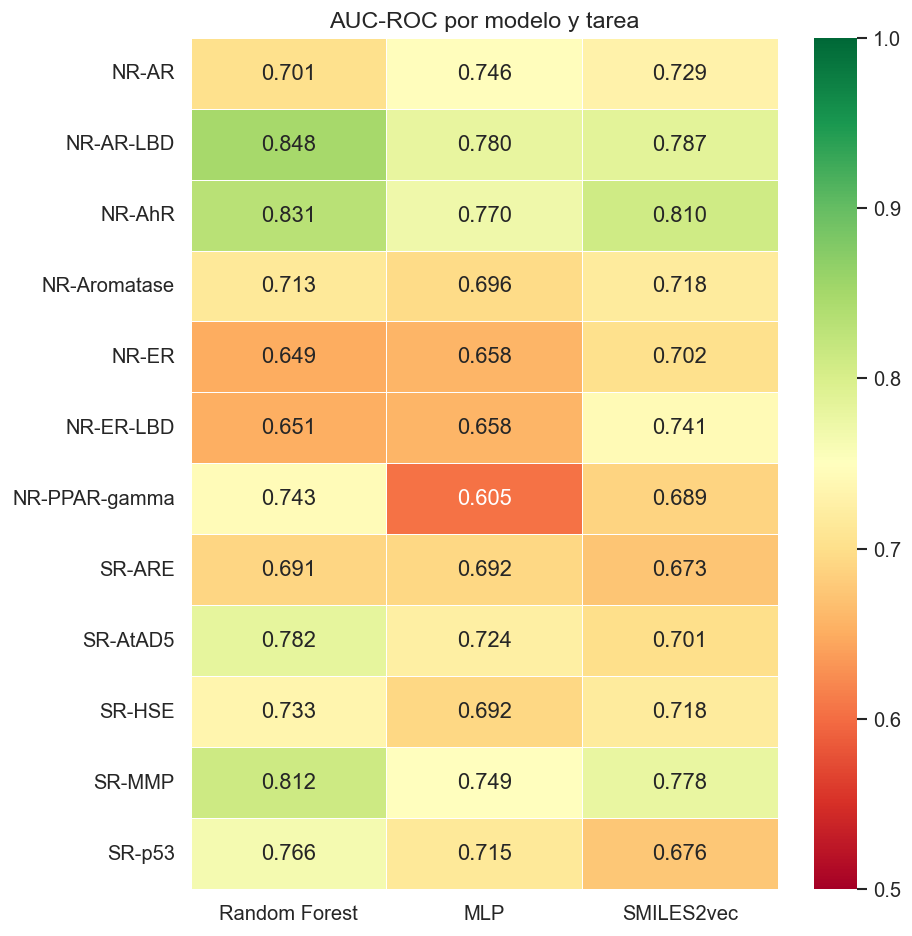

In [13]:
df_heat = pd.DataFrame(auc_matrix.T, index=TASK_NAMES, columns=MODELOS)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(df_heat, annot=True, fmt=".3f", cmap="RdYlGn", center=0.75,
            vmin=0.5, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("AUC-ROC por modelo y tarea", fontsize=14)
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_heatmap_auc.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Curvas ROC por tarea

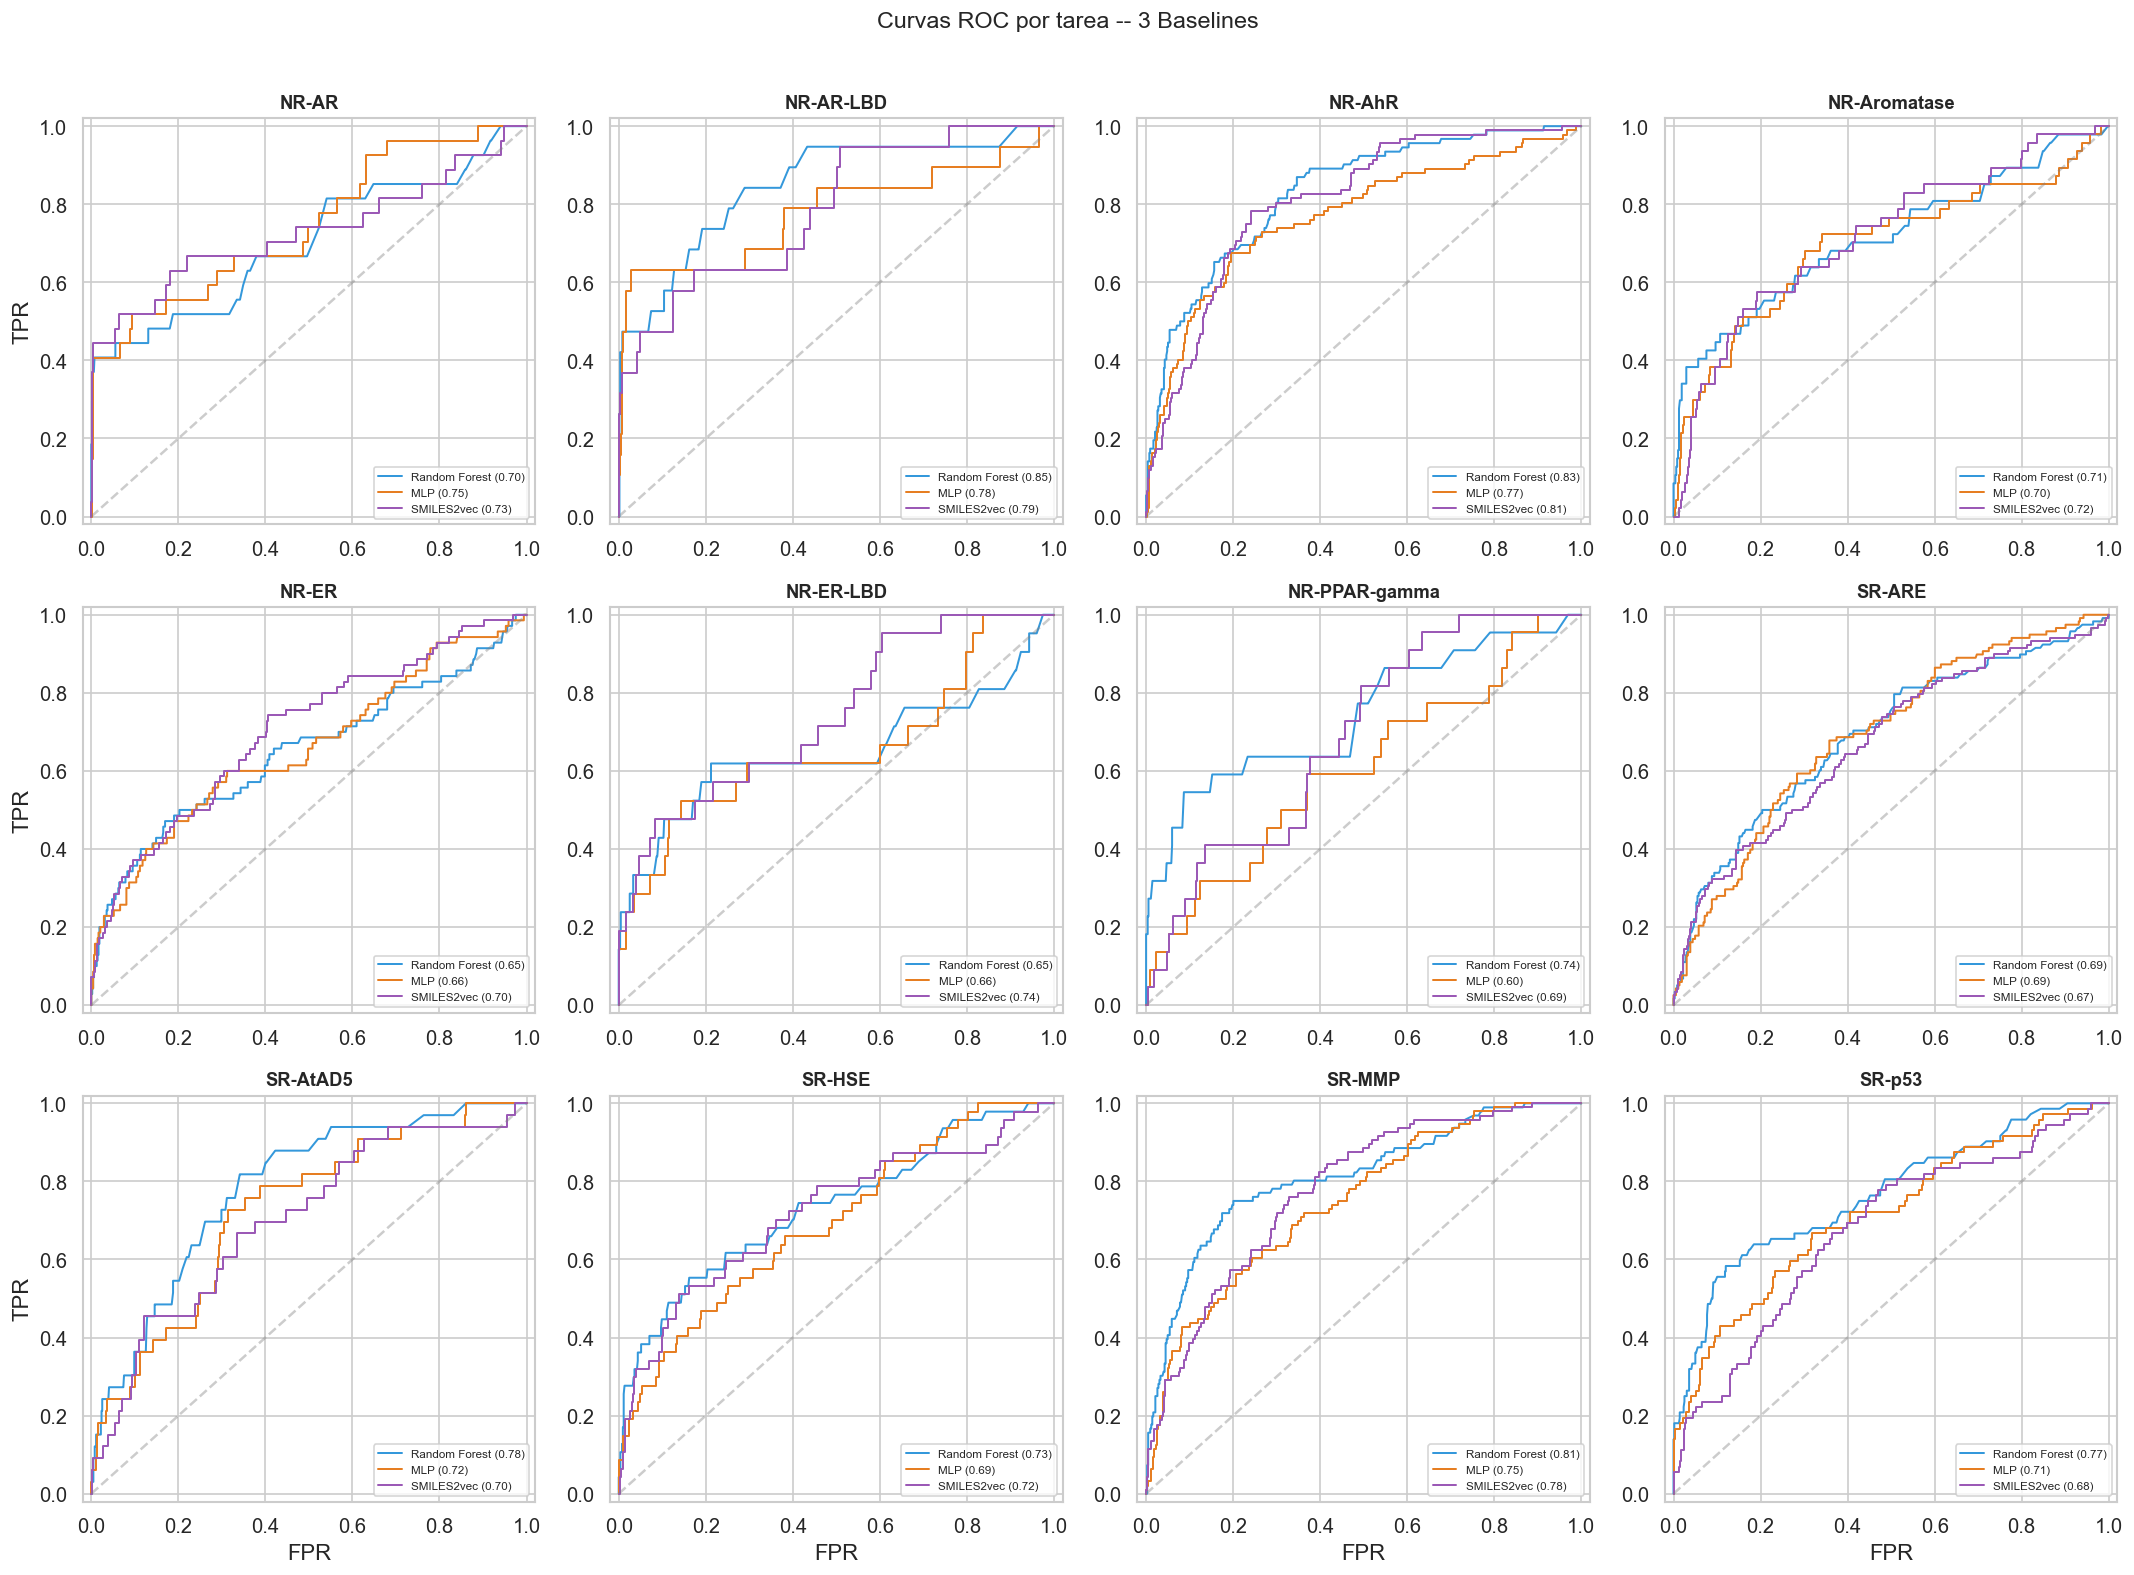

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes_flat = axes.flatten()

for t in range(N_TASKS):
    ax = axes_flat[t]
    valid = mask_te[:, t].astype(bool)
    y_t = y_te[valid, t]

    if len(np.unique(y_t)) < 2:
        ax.text(0.5, 0.5, "Sin datos\nsuficientes", ha="center", va="center")
        ax.set_title(TASK_NAMES[t], fontsize=10)
        continue

    for i, (nombre, color, preds) in enumerate(zip(MODELOS, COLORES, all_preds)):
        pred_t = preds[valid, t]
        fpr, tpr, _ = roc_curve(y_t, pred_t)
        auc_val = aucs_dict_list[i].get(TASK_NAMES[t], 0.5)
        ax.plot(fpr, tpr, color=color, linewidth=1.2,
                label=f"{nombre} ({auc_val:.2f})")

    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.4)
    ax.set_title(TASK_NAMES[t], fontsize=11, fontweight="bold")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=7, loc="lower right")
    if t >= 8:
        ax.set_xlabel("FPR")
    if t % 4 == 0:
        ax.set_ylabel("TPR")

plt.suptitle("Curvas ROC por tarea -- 3 Baselines", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_curvas_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. AUC-ROC vs AUPRC por modelo

AUPRC es mas informativo que AUC-ROC cuando hay desbalance severo.

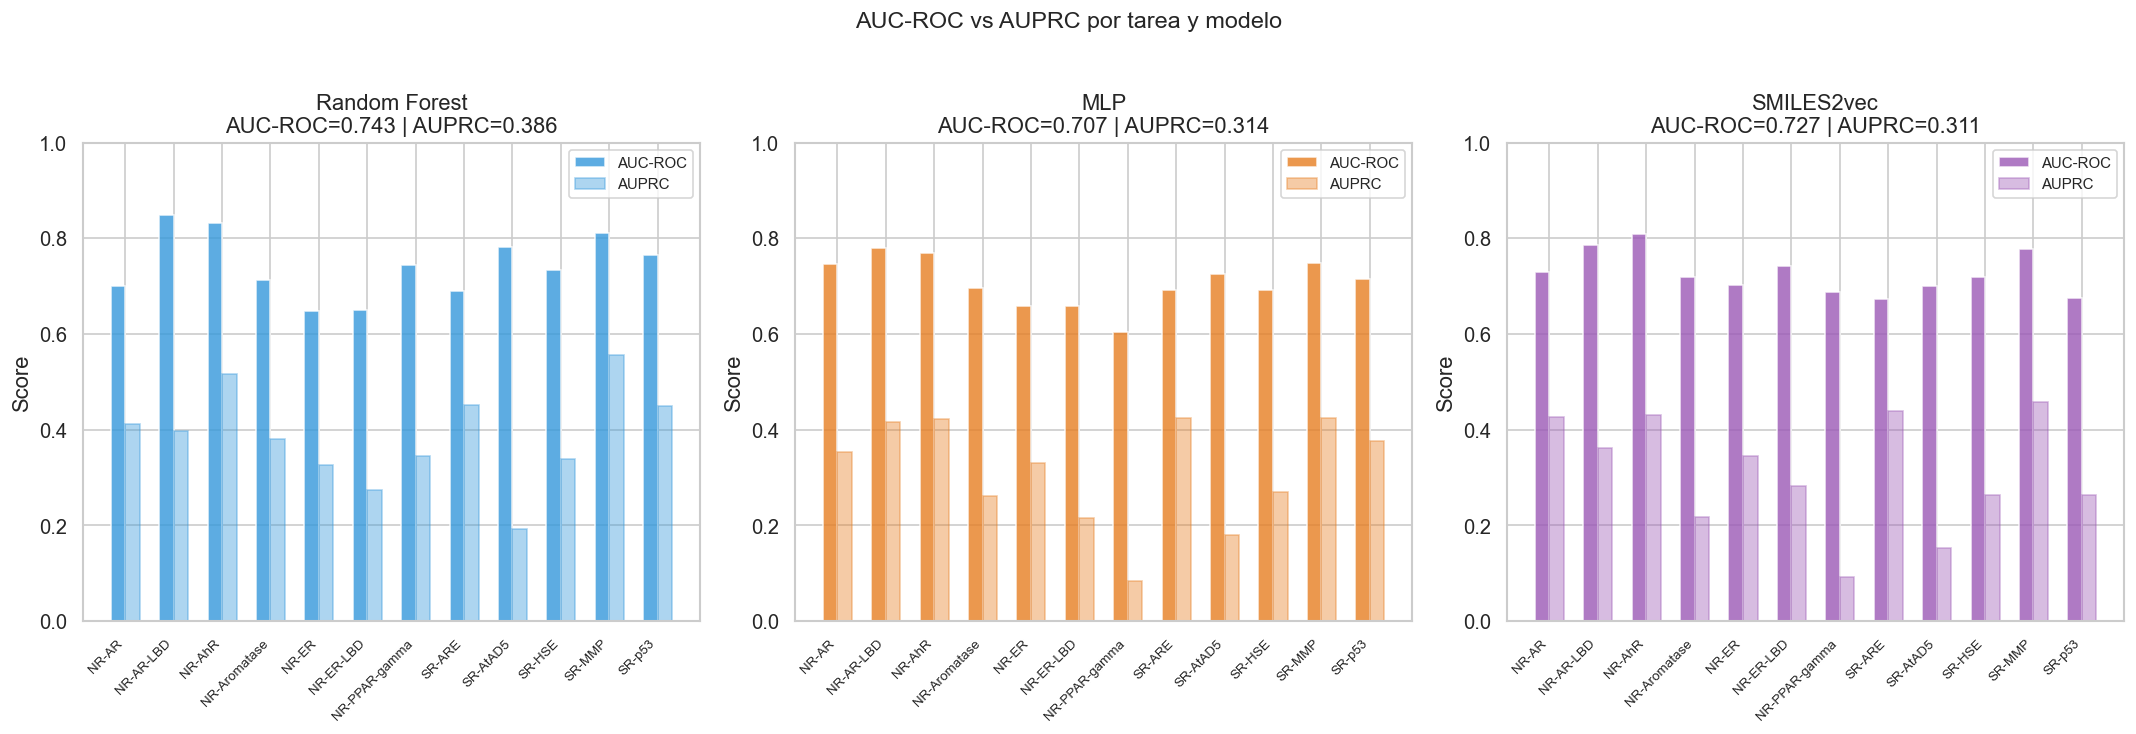

AUPRC suele ser mucho mas bajo que AUC-ROC en tareas desbalanceadas.
La GNN tambien se evaluara con AUPRC para comparacion justa.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (nombre, color) in enumerate(zip(MODELOS, COLORES)):
    ax = axes[i]
    roc_vals = [aucs_dict_list[i].get(t, np.nan) for t in TASK_NAMES]
    prc_vals = [auprcs_dict_list[i].get(t, np.nan) for t in TASK_NAMES]

    x_pos = np.arange(N_TASKS)
    ax.bar(x_pos - 0.15, roc_vals, 0.3, label="AUC-ROC", color=color, alpha=0.8)
    ax.bar(x_pos + 0.15, prc_vals, 0.3, label="AUPRC", color=color, alpha=0.4,
           edgecolor=color, linewidth=1)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(TASK_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Score")
    ax.set_title(f"{nombre}\nAUC-ROC={medias_auc[i]:.3f} | AUPRC={medias_auprc[i]:.3f}")
    ax.legend(fontsize=9)

plt.suptitle("AUC-ROC vs AUPRC por tarea y modelo", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_auc_vs_auprc.png", dpi=150, bbox_inches="tight")
plt.show()

print("AUPRC suele ser mucho mas bajo que AUC-ROC en tareas desbalanceadas.")
print("La GNN tambien se evaluara con AUPRC para comparacion justa.")

## 12. Analisis de dificultad por tarea

Hay relacion entre el porcentaje de positivos (desbalance) y la dificultad de prediccion?

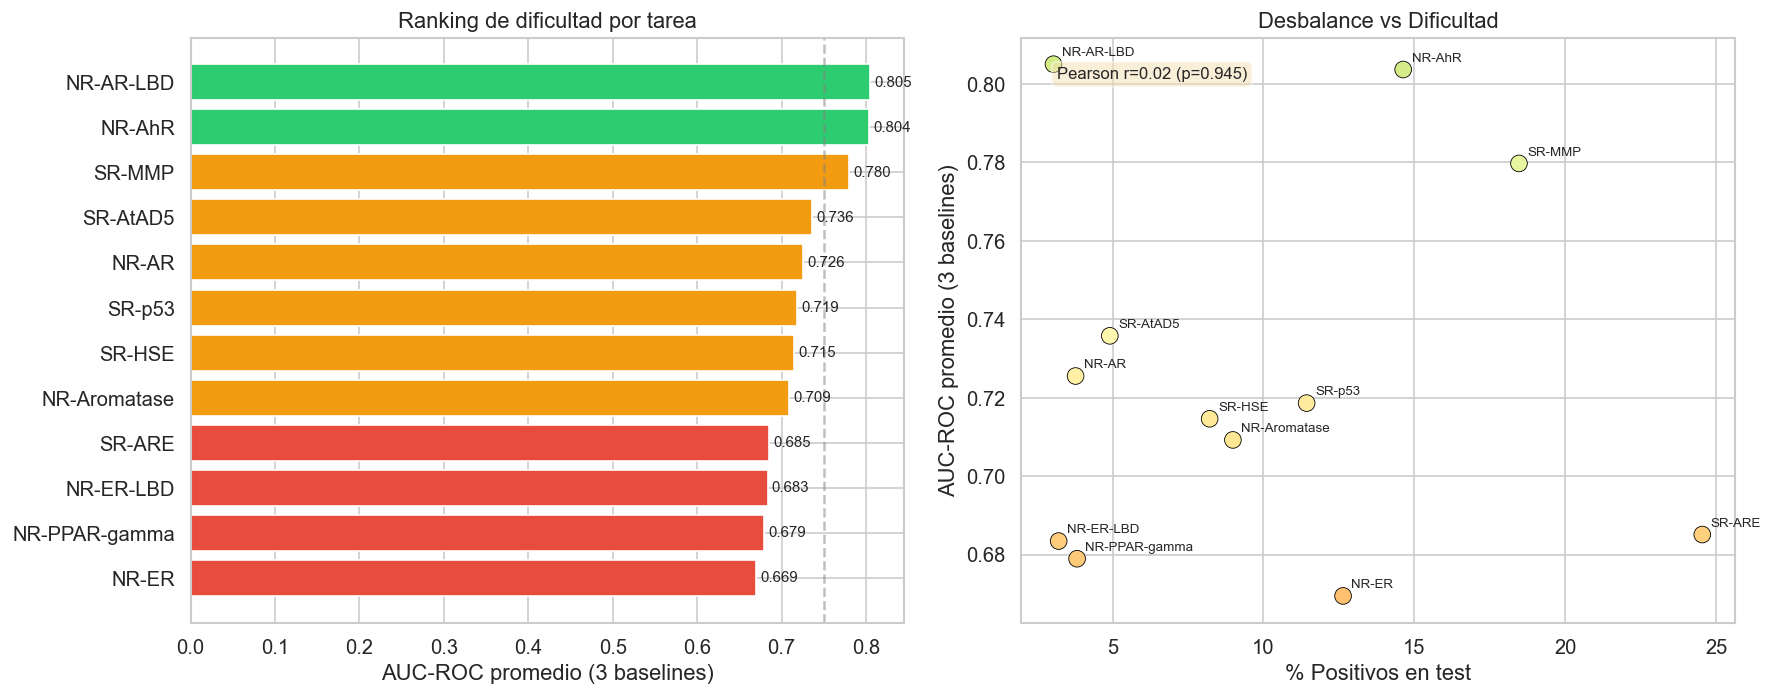

In [16]:
auc_promedio_por_tarea = auc_matrix.mean(axis=0)

pct_pos_test = []
for t in range(N_TASKS):
    valid = mask_te[:, t].astype(bool)
    n_v = valid.sum()
    pct_pos_test.append(100.0 * y_te[valid, t].sum() / n_v if n_v > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ranking de dificultad
orden = np.argsort(auc_promedio_por_tarea)
tareas_ordenadas = [TASK_NAMES[i] for i in orden]
auc_ordenado = auc_promedio_por_tarea[orden]
colores_dif = ["#e74c3c" if v < 0.7 else "#f39c12" if v < 0.8 else "#2ecc71"
               for v in auc_ordenado]

axes[0].barh(range(N_TASKS), auc_ordenado, color=colores_dif, edgecolor="white")
axes[0].set_yticks(range(N_TASKS))
axes[0].set_yticklabels(tareas_ordenadas)
axes[0].set_xlabel("AUC-ROC promedio (3 baselines)")
axes[0].set_title("Ranking de dificultad por tarea")
axes[0].axvline(0.75, color="gray", linestyle="--", alpha=0.5)
for i, val in enumerate(auc_ordenado):
    axes[0].text(val + 0.005, i, f"{val:.3f}", va="center", fontsize=9)

# Scatter desbalance vs AUC
axes[1].scatter(pct_pos_test, auc_promedio_por_tarea, s=100,
                c=auc_promedio_por_tarea, cmap="RdYlGn", edgecolors="black",
                linewidth=0.5, vmin=0.5, vmax=1.0, zorder=3)
for t in range(N_TASKS):
    axes[1].annotate(TASK_NAMES[t], (pct_pos_test[t], auc_promedio_por_tarea[t]),
                     textcoords="offset points", xytext=(5, 5), fontsize=8)
axes[1].set_xlabel("% Positivos en test")
axes[1].set_ylabel("AUC-ROC promedio (3 baselines)")
axes[1].set_title("Desbalance vs Dificultad")

r, p = stats.pearsonr(pct_pos_test, auc_promedio_por_tarea)
axes[1].text(0.05, 0.95, f"Pearson r={r:.2f} (p={p:.3f})",
             transform=axes[1].transAxes, fontsize=10, va="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / "07_dificultad_por_tarea.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Mejora sobre Random Forest por tarea

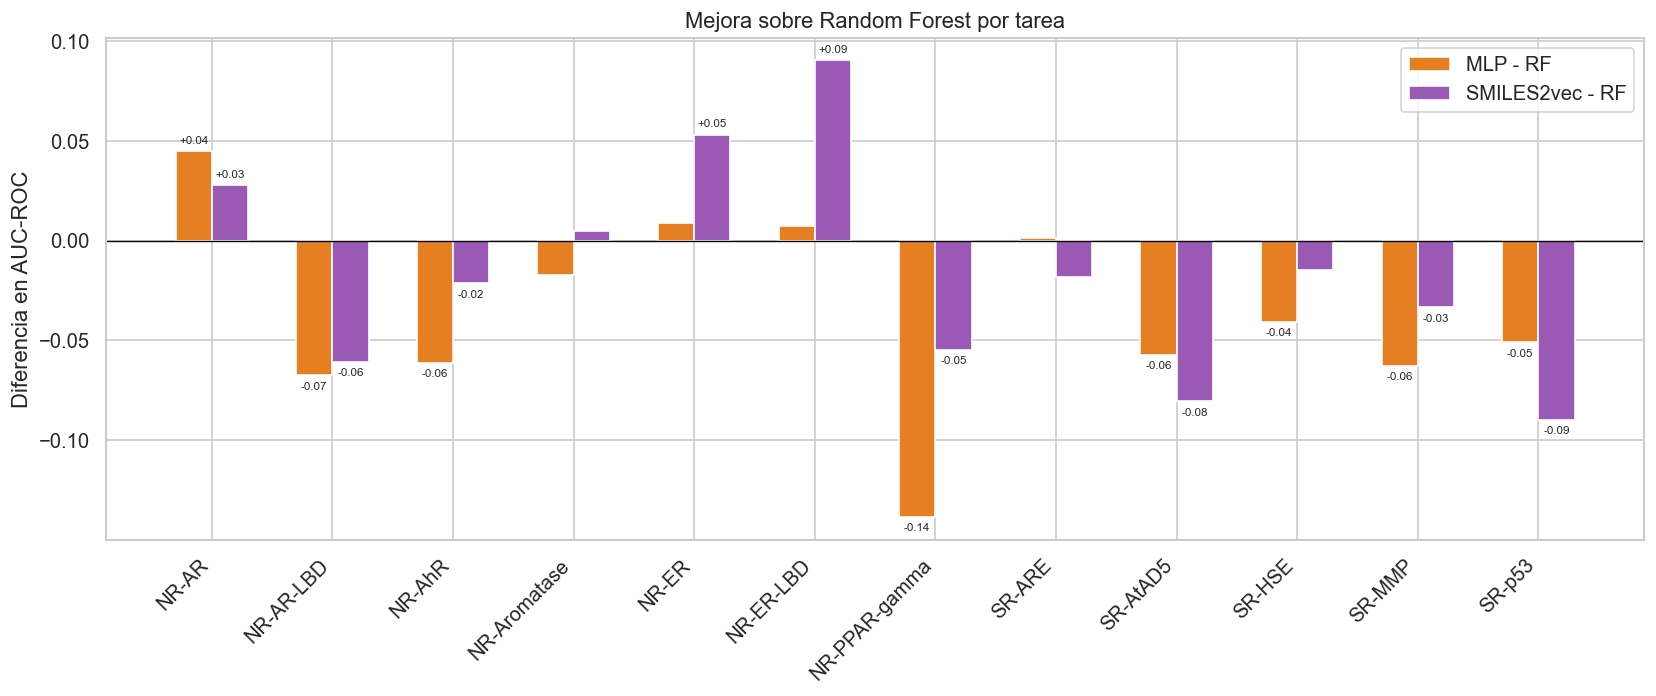

Mejora promedio MLP sobre RF:       -0.0362
Mejora promedio SMILES2vec sobre RF: -0.0165
Tareas donde RF gana a ambos: ['NR-AR-LBD', 'NR-AhR', 'NR-PPAR-gamma', 'SR-AtAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


In [17]:
diff_mlp_rf = auc_matrix[1] - auc_matrix[0]
diff_s2v_rf = auc_matrix[2] - auc_matrix[0]

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(N_TASKS)
ax.bar(x_pos - 0.15, diff_mlp_rf, 0.3, label="MLP - RF", color="#e67e22")
ax.bar(x_pos + 0.15, diff_s2v_rf, 0.3, label="SMILES2vec - RF", color="#9b59b6")

ax.set_xticks(x_pos)
ax.set_xticklabels(TASK_NAMES, rotation=45, ha="right")
ax.set_ylabel("Diferencia en AUC-ROC")
ax.set_title("Mejora sobre Random Forest por tarea")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()

for i in range(N_TASKS):
    for diff, offset in [(diff_mlp_rf[i], -0.15), (diff_s2v_rf[i], 0.15)]:
        if abs(diff) > 0.02:
            va = "bottom" if diff > 0 else "top"
            ax.text(i + offset, diff + (0.003 if diff > 0 else -0.003),
                    f"{diff:+.2f}", ha="center", fontsize=7, va=va)

plt.tight_layout()
plt.savefig(FIG_DIR / "08_mejora_sobre_rf.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mejora promedio MLP sobre RF:       {diff_mlp_rf.mean():+.4f}")
print(f"Mejora promedio SMILES2vec sobre RF: {diff_s2v_rf.mean():+.4f}")
rf_gana = [TASK_NAMES[t] for t in range(N_TASKS) if diff_mlp_rf[t] < 0 and diff_s2v_rf[t] < 0]
if rf_gana:
    print(f"Tareas donde RF gana a ambos: {rf_gana}")

## 14. Distribucion de predicciones: positivos vs negativos

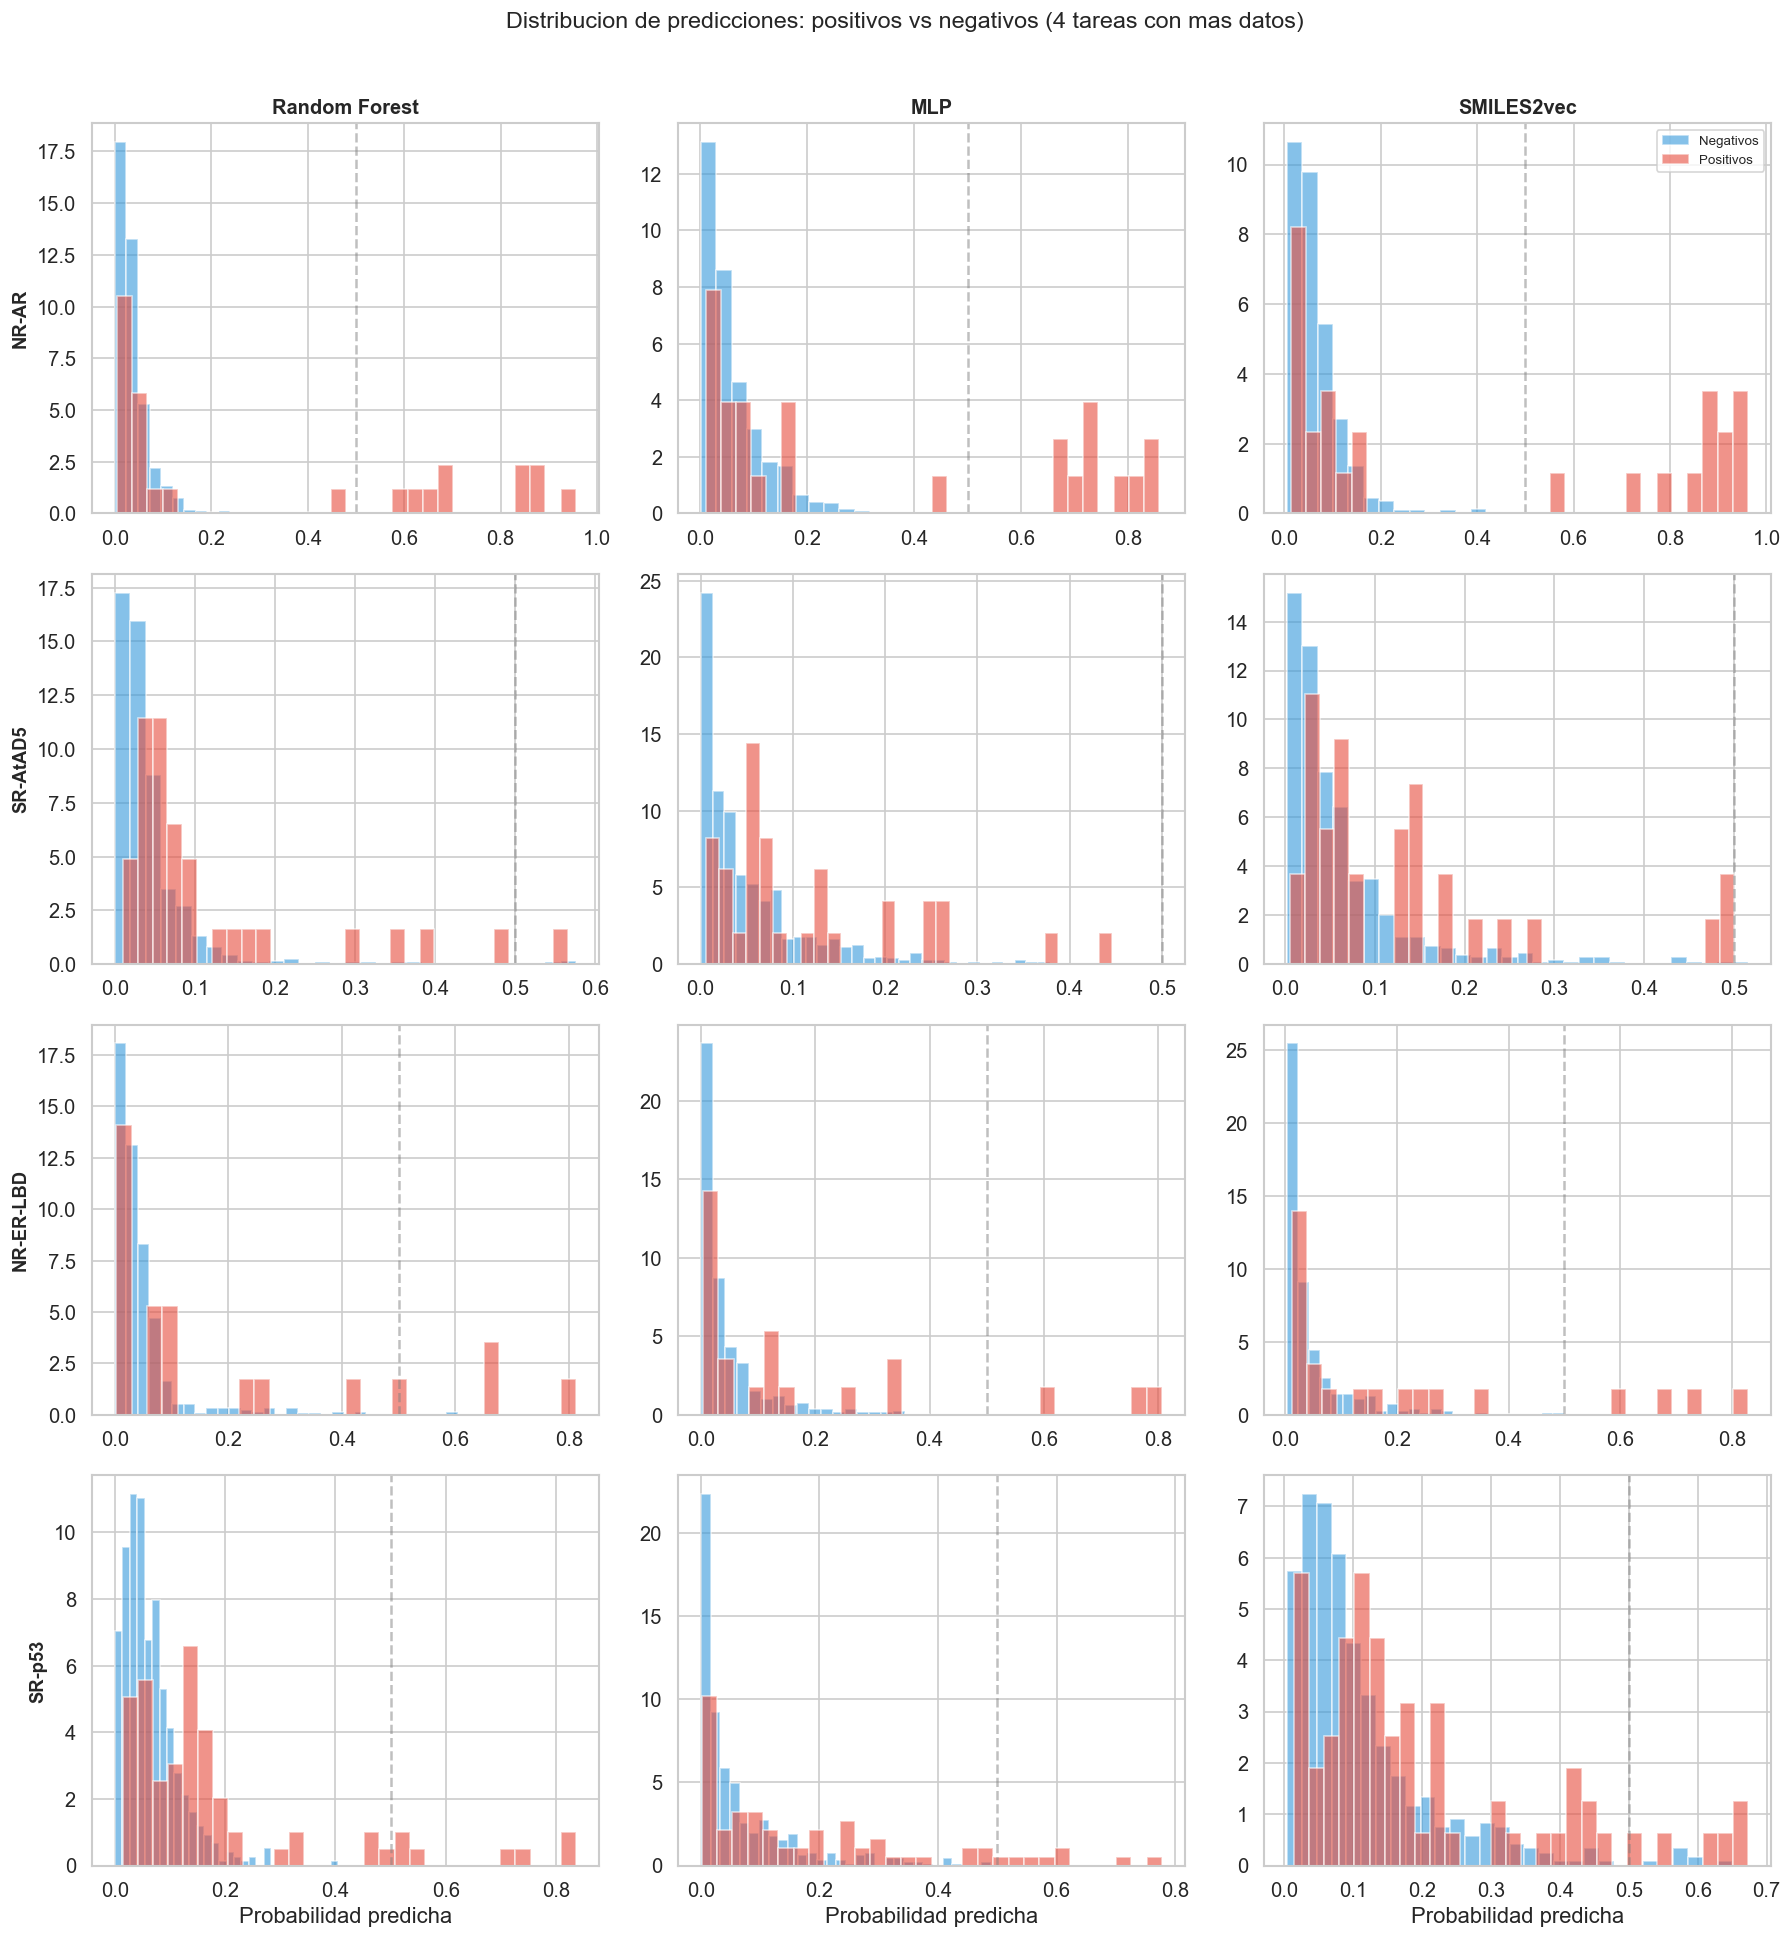

In [18]:
tareas_top4 = sorted(range(N_TASKS), key=lambda t: mask_te[:, t].sum(), reverse=True)[:4]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

for row, t in enumerate(tareas_top4):
    valid = mask_te[:, t].astype(bool)
    y_t = y_te[valid, t]
    idx_pos = y_t == 1
    idx_neg = y_t == 0

    for col, (nombre, color, preds) in enumerate(zip(MODELOS, COLORES, all_preds)):
        ax = axes[row, col]
        pred_t = preds[valid, t]

        ax.hist(pred_t[idx_neg], bins=30, alpha=0.6, color="#3498db",
                label="Negativos", density=True)
        ax.hist(pred_t[idx_pos], bins=30, alpha=0.6, color="#e74c3c",
                label="Positivos", density=True)
        ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5)

        if row == 0:
            ax.set_title(nombre, fontsize=12, fontweight="bold")
        if col == 0:
            ax.set_ylabel(TASK_NAMES[t], fontsize=11, fontweight="bold")
        if row == 3:
            ax.set_xlabel("Probabilidad predicha")
        if row == 0 and col == 2:
            ax.legend(fontsize=8)

plt.suptitle("Distribucion de predicciones: positivos vs negativos (4 tareas con mas datos)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_distribucion_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Varianza entre modelos (consenso vs desacuerdo)

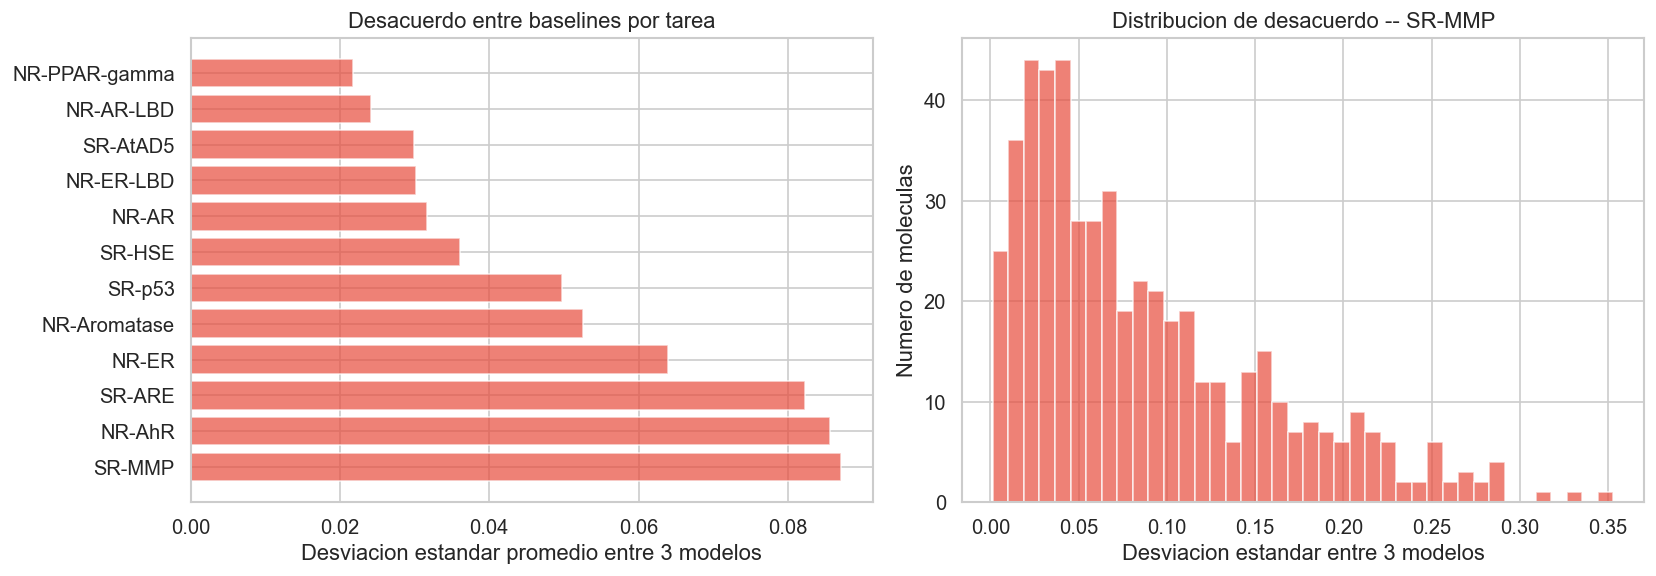

Tareas con mayor desacuerdo entre baselines:
  1. SR-MMP: std=0.0870
  2. NR-AhR: std=0.0857
  3. SR-ARE: std=0.0822


In [19]:
preds_stack = np.stack(all_preds, axis=0)  # (3, N, 12)
std_por_molecula = preds_stack.std(axis=0)  # (N, 12)
mean_std_por_tarea = []
for t in range(N_TASKS):
    valid = mask_te[:, t].astype(bool)
    mean_std_por_tarea.append(std_por_molecula[valid, t].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_std = np.argsort(mean_std_por_tarea)[::-1]
axes[0].barh(range(N_TASKS),
             [mean_std_por_tarea[i] for i in orden_std],
             color="#e74c3c", alpha=0.7)
axes[0].set_yticks(range(N_TASKS))
axes[0].set_yticklabels([TASK_NAMES[i] for i in orden_std])
axes[0].set_xlabel("Desviacion estandar promedio entre 3 modelos")
axes[0].set_title("Desacuerdo entre baselines por tarea")

t_alto = orden_std[0]
valid = mask_te[:, t_alto].astype(bool)
axes[1].hist(std_por_molecula[valid, t_alto], bins=40, color="#e74c3c",
             alpha=0.7, edgecolor="white")
axes[1].set_xlabel("Desviacion estandar entre 3 modelos")
axes[1].set_ylabel("Numero de moleculas")
axes[1].set_title(f"Distribucion de desacuerdo -- {TASK_NAMES[t_alto]}")

plt.tight_layout()
plt.savefig(FIG_DIR / "10_desacuerdo_entre_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

print("Tareas con mayor desacuerdo entre baselines:")
for rank, idx in enumerate(orden_std[:3]):
    print(f"  {rank+1}. {TASK_NAMES[idx]}: std={mean_std_por_tarea[idx]:.4f}")

---
## 16. Resumen y conclusiones

In [20]:
print("=" * 70)
print("RESUMEN DE BASELINES -- Tox21 (scaffold split)")
print("=" * 70)
print(f"{'Modelo':<20} {'AUC-ROC':>10} {'AUPRC':>10} {'Tiempo':>10}")
print("-" * 50)
for nombre, auc, auprc, t in zip(MODELOS, medias_auc, medias_auprc, tiempos):
    print(f"{nombre:<20} {auc:>10.4f} {auprc:>10.4f} {t:>8.0f}s")
print("-" * 50)
mejor_idx = np.argmax(medias_auc)
print(f"\nMejor baseline: {MODELOS[mejor_idx]} (AUC={medias_auc[mejor_idx]:.4f})")
print(f"Objetivo GNN-GIN (Fase III): AUC > {max(medias_auc):.3f}")
print(f"Objetivo de la literatura (GCN): AUC ~ 0.83")

orden_fac = np.argsort(auc_promedio_por_tarea)[::-1]
print(f"\nTareas mas faciles (mayor AUC promedio):")
for i in orden_fac[:3]:
    print(f"  {TASK_NAMES[i]:20s} AUC={auc_promedio_por_tarea[i]:.3f}")
print(f"Tareas mas dificiles (menor AUC promedio):")
for i in orden_fac[-3:]:
    print(f"  {TASK_NAMES[i]:20s} AUC={auc_promedio_por_tarea[i]:.3f}")

RESUMEN DE BASELINES -- Tox21 (scaffold split)
Modelo                  AUC-ROC      AUPRC     Tiempo
--------------------------------------------------
Random Forest            0.7433     0.3864      196s
MLP                      0.7071     0.3136        4s
SMILES2vec               0.7268     0.3110      157s
--------------------------------------------------

Mejor baseline: Random Forest (AUC=0.7433)
Objetivo GNN-GIN (Fase III): AUC > 0.743
Objetivo de la literatura (GCN): AUC ~ 0.83

Tareas mas faciles (mayor AUC promedio):
  NR-AR-LBD            AUC=0.805
  NR-AhR               AUC=0.804
  SR-MMP               AUC=0.780
Tareas mas dificiles (menor AUC promedio):
  NR-ER-LBD            AUC=0.683
  NR-PPAR-gamma        AUC=0.679
  NR-ER                AUC=0.669


In [21]:
print(f"\nGraficos guardados en: {FIG_DIR}")
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name}")
print(f"\nCSV de resultados: {OUT_DIR / 'baseline_results.csv'}")


Graficos guardados en: c:\Users\mateo\Desktop\JIC2026\outputs\baselines
  01_auc_por_tarea.png
  02_media_vs_literatura.png
  03_curvas_entrenamiento.png
  04_heatmap_auc.png
  05_curvas_roc.png
  06_auc_vs_auprc.png
  07_dificultad_por_tarea.png
  08_mejora_sobre_rf.png
  09_distribucion_predicciones.png
  10_desacuerdo_entre_modelos.png

CSV de resultados: c:\Users\mateo\Desktop\JIC2026\outputs\results\baseline_results.csv


### Interpretacion

1. **Sanidad de datos**: Si el RF alcanzo AUC > 0.65, el pipeline de datos esta correcto.

2. **Jerarquia esperada**: RF < MLP <= SMILES2vec. Si el RF supera al MLP,
   el MLP necesita mas epocas o ajuste de learning rate.

3. **Gap con la GNN**: La diferencia entre el mejor baseline y el objetivo de la GNN (>0.82)
   es el gap que la representacion de grafo molecular debe cerrar.

4. **Tareas dificiles**: Las tareas con peor AUC en los 3 baselines son las que
   mas se beneficiarian de la GNN, porque la informacion topologica del grafo
   puede capturar patrones que los fingerprints no capturan.

5. **AUPRC vs AUC-ROC**: La diferencia grande confirma desbalance severo.
   Reportar ambas metricas es importante para el paper.

6. **Desacuerdo entre modelos**: Las tareas con alto desacuerdo son las mas
   interesantes para la GNN -- si las 3 representaciones discrepan,
   la estructura del grafo puede aportar informacion diferenciadora.

### Siguiente paso

**Fase III**: Entrenar la GNN-GIN y verificar que supera estos baselines.